# U.S. Airline Operational Performance Analysis

**Author**: Ashwin Parthasarathy

**Dataset**: U.S. Bureau of Transportation Statistics - Reporting Carrier On-Time Performance

This project builds a reproducible Python data workflow to analyze recent U.S. airline operational performance. Using more than 11 million flight records from January 2025 through July 2026, the analysis examines flight reliability across time, reporting airline, major U.S. airports, and BTS-attributed delay causes.

**Analysis questions**
The analysis focuses on answering the following questions:
1. How do departure and arrival delay rates vary over time?
2. How does arrival reliability differ across reporting airlines?
3. How does departure reliability differ among the busiest U.S. airports?
4. Which BTS-attributed causes account for the largest share of attributed arrival delay minutes?
5. How does the composition of attributed delay minutes differ among major origin airports?

## 1. Setup
---

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option("display.max_columns", None)

## 2. Data Ingestion
---

### Dataset Source and Scope

This analysis uses the U.S. Bureau of Transportation Statistics (BTS) **Reporting Carrier On-Time Performance (1987-present)** dataset. The dataset contains flight-level operational data for non-stop U.S. domestic flights reported by qualifying air carriers, including scheduled and actual departure and arrival times, cancellations, diversions, taxi times, delay and cancellation causes, air time, and flight distance.

**Official data source**: [BTS Reporting Carrier On-Time Performance](https://transtats.bts.gov/TableInfo.asp?QO_fu146_anzr=b0-gvzr&V0s1_b0yB=D&gnoyr_VQ=FGJ)

The analysis covers **January 2025 through July 2026**, representing 19 monthly data partitions. Raw monthly BTS ZIP archives are downloaded reproducibly and converted to Parquet files before analysis.

The preparation workflow retains **41 fields** needed for this project, including flight dates, carrier and airport identifiers, scheduled and actual times, delay measures, cancellation and diversion indicators, flight duration, distance, and BTS-attributed delay causes. Restricting the processed dataset to the fields required for analysis reduces storage and memory requirements while preserving the original values used in the analytical workflow.

Because the complete dataset contains more than 11 million records, the analysis processes monthly Parquet partitions rather than loading the entire dataset into memory at once.

The raw and processed datasets are excluded from Git because of their size. The repository instead includes scripts that reproduce the data acquisition and preparation workflows.

### Reproducing the Local Dataset

The raw and processed datasets are not stored in the repository because of their size. They can be reproduced from the project root using the provided scripts.

**Download the BTS monthly archives**
```bash
python scripts/download_bts_data.py \
    --start-year 2025 \
    --start-month 1 \
    --end-year 2026 \
    --end-month 7
```

**Convert the downloaded monthly archives into the focused Parquet files used by this notebook**
```bash
python scripts/prepare_bts_data.py \
    --start-year 2025 \
    --start-month 1 \
    --end-year 2026 \
    --end-month 7
```

NOTE: `prepare_bts_data.py` supports an optional `--overwrite` flag when existing files need to be regenerated.

After these steps, the processed monthly files are available in the `data/processed` folder and can be loaded by the notebook.

In [3]:
PROJECT_ROOT = Path.cwd()
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"

parquet_files = sorted(PROCESSED_DATA_DIR.glob("bts_flights_*.parquet"))

print(f"Monthly files found: {len(parquet_files)}")
print(f"First file: {parquet_files[0].name}")
print(f"Last file:  {parquet_files[-1].name}")

Monthly files found: 19
First file: bts_flights_2025_01.parquet
Last file:  bts_flights_2026_07.parquet


In [4]:
# Take inventory of all files and inspect for data sufficiency (no. of records, start date, end date)
monthly_inventory = []

for path in parquet_files:
    dates = pd.read_parquet(
        path,
        columns=["FlightDate"],
    )

    monthly_inventory.append(
        {
            "file": path.name,
            "rows": len(dates),
            "start_date": dates["FlightDate"].min(),
            "end_date": dates["FlightDate"].max(),
        }
    )

inventory_df = pd.DataFrame(monthly_inventory)
inventory_df

,file,rows,start_date,end_date
0,bts_flights_2025_01.parquet,539747,2025-01-01,2025-01-31
1,bts_flights_2025_02.parquet,504884,2025-02-01,2025-02-28
2,bts_flights_2025_03.parquet,600872,2025-03-01,2025-03-31
3,bts_flights_2025_04.parquet,583950,2025-04-01,2025-04-30
4,bts_flights_2025_05.parquet,605648,2025-05-01,2025-05-31
5,bts_flights_2025_06.parquet,611575,2025-06-01,2025-06-30
6,bts_flights_2025_07.parquet,631428,2025-07-01,2025-07-31
7,bts_flights_2025_08.parquet,602378,2025-08-01,2025-08-31
8,bts_flights_2025_09.parquet,562439,2025-09-01,2025-09-30
9,bts_flights_2025_10.parquet,605844,2025-10-01,2025-10-31


In [5]:
print(f"Total rows: {inventory_df['rows'].sum():,}")
print("Date range: ", inventory_df['start_date'].min(), " to ", inventory_df['end_date'].max())

Total rows: 11,121,962
Date range:  2025-01-01 00:00:00  to  2026-07-31 00:00:00


In [6]:
# Sample one month's data
sample_df = pd.read_parquet(parquet_files[0])

print(f"Shape: {sample_df.shape}")
sample_df.head()

Shape: (539747, 41)


,Year,Month,DayOfWeek,FlightDate,Reporting_Airline,DOT_ID_Reporting_Airline,Flight_Number_Reporting_Airline,OriginAirportID,Origin,OriginCityName,OriginState,DestAirportID,Dest,DestCityName,DestState,CRSDepTime,DepTime,DepDelay,DepDelayMinutes,DepDel15,DepTimeBlk,TaxiOut,TaxiIn,CRSArrTime,ArrTime,ArrDelay,ArrDelayMinutes,ArrDel15,ArrTimeBlk,Cancelled,CancellationCode,Diverted,CRSElapsedTime,ActualElapsedTime,AirTime,Distance,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
0,2025,1,3,2025-01-01,AA,19805,1,12478,JFK,"New York, NY",NY,12892,LAX,"Los Angeles, CA",CA,659,656.0,-3.0,0.0,0.0,0600-0659,23.0,9.0,1020,1013.0,-7.0,0.0,0.0,1000-1059,0.0,NaN,0.0,381.0,377.0,345.0,2475.0,NaN,NaN,NaN,NaN,NaN
1,2025,1,4,2025-01-02,AA,19805,1,12478,JFK,"New York, NY",NY,12892,LAX,"Los Angeles, CA",CA,659,652.0,-7.0,0.0,0.0,0600-0659,30.0,7.0,1020,1022.0,2.0,2.0,0.0,1000-1059,0.0,NaN,0.0,381.0,390.0,353.0,2475.0,NaN,NaN,NaN,NaN,NaN
2,2025,1,5,2025-01-03,AA,19805,1,12478,JFK,"New York, NY",NY,12892,LAX,"Los Angeles, CA",CA,659,652.0,-7.0,0.0,0.0,0600-0659,13.0,11.0,1020,1003.0,-17.0,0.0,0.0,1000-1059,0.0,NaN,0.0,381.0,371.0,347.0,2475.0,NaN,NaN,NaN,NaN,NaN
3,2025,1,6,2025-01-04,AA,19805,1,12478,JFK,"New York, NY",NY,12892,LAX,"Los Angeles, CA",CA,700,653.0,-7.0,0.0,0.0,0700-0759,24.0,10.0,1026,1016.0,-10.0,0.0,0.0,1000-1059,0.0,NaN,0.0,386.0,383.0,349.0,2475.0,NaN,NaN,NaN,NaN,NaN
4,2025,1,7,2025-01-05,AA,19805,1,12478,JFK,"New York, NY",NY,12892,LAX,"Los Angeles, CA",CA,659,655.0,-4.0,0.0,0.0,0600-0659,26.0,5.0,1020,1013.0,-7.0,0.0,0.0,1000-1059,0.0,NaN,0.0,381.0,378.0,347.0,2475.0,NaN,NaN,NaN,NaN,NaN


In [7]:
sample_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 539747 entries, 0 to 539746
Data columns (total 41 columns):
 #   Column                           Non-Null Count   Dtype         
---  ------                           --------------   -----         
 0   Year                             539747 non-null  int64         
 1   Month                            539747 non-null  int64         
 2   DayOfWeek                        539747 non-null  int64         
 3   FlightDate                       539747 non-null  datetime64[us]
 4   Reporting_Airline                539747 non-null  str           
 5   DOT_ID_Reporting_Airline         539747 non-null  int64         
 6   Flight_Number_Reporting_Airline  539747 non-null  int64         
 7   OriginAirportID                  539747 non-null  int64         
 8   Origin                           539747 non-null  str           
 9   OriginCityName                   539747 non-null  str           
 10  OriginState                      539747 non-null  str  

In [8]:
# Summary of dataset

print(f"Monthly files: {len(parquet_files)}")
print(f"Total rows: {inventory_df['rows'].sum()}")
print(f"Date range: {inventory_df['start_date'].min()} to {inventory_df['end_date'].max()}")

Monthly files: 19
Total rows: 11121962
Date range: 2025-01-01 00:00:00 to 2026-07-31 00:00:00


> The working dataset contains 11.12M flight records across 19 monthly partitions. To keep the workflow reproducible and memory-efficient, the analysis processes monthly parquet partitions rather than loading the entire dataset into memory at once.

## 3. Data Cleaning
---
Before applying any cleaning rules, the dataset is assessed for missing values, unexpected values, and fields whose missingness is structurally expected.

This distinction is important for flight operations data because cancelled or diverted flights may legitimately lack arrival or elapsed-time measurements. Cleaning rules are therefore based on the operational meaning of each field rather than treating every missing value as an error.

### Data Quality Assessment

In [9]:
missing_summary = (
    sample_df.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame("missing_count")
)

missing_summary["missing_pct"] = missing_summary["missing_count"]/len(sample_df) * 100

missing_summary

,missing_count,missing_pct
CancellationCode,523435,96.977843
WeatherDelay,441617,81.819260
CarrierDelay,441617,81.819260
LateAircraftDelay,441617,81.819260
NASDelay,441617,81.819260
SecurityDelay,441617,81.819260
ArrDelay,17478,3.238184
AirTime,17478,3.238184
ActualElapsedTime,17478,3.238184
ArrDelayMinutes,17478,3.238184


> - `CancellationCode` is missing for 96.98% of rows. This is likely correct because this field should be populated only for meaningful flight cancellations.
> - All five delay cause fields have exactly the same missing counts (441,617 - 81.82%). This indicates that these fields are populated under specific operational conditions.
> - Departure fields such as `DepTime`, `DepDelay`, `DepDel15` are missing for about 2.95% of flights.
> - Arrival-related fields are missing slightly more often, around 3.24%.
> - Core schedule and identity fields (airline, airport, date, distance, scheduled time) do not have missing values. These fields therefore provide a foundation for the core grouping and scheduling analysis.

In [10]:
fields_to_check = [
    "DepTime",
    "DepDelay",
    "ArrTime",
    "ArrDelay",
    "ActualElapsedTime",
    "AirTime",
    "CancellationCode",
]

for column in fields_to_check:
    print(f"\n ***** {column} *****")

    print(
        pd.crosstab(
            [
                sample_df["Cancelled"],
                sample_df["Diverted"],
            ],
            sample_df[column].isna(),
            rownames=["Cancelled", "Diverted"],
            colnames=["Missing"],
        )
    )


 ***** DepTime *****
Missing              False  True 
Cancelled Diverted               
0.0       0.0       522269      0
          1.0         1166      0
1.0       0.0          426  15886

 ***** DepDelay *****
Missing              False  True 
Cancelled Diverted               
0.0       0.0       522269      0
          1.0         1166      0
1.0       0.0          389  15923

 ***** ArrTime *****
Missing              False  True 
Cancelled Diverted               
0.0       0.0       522269      0
          1.0          898    268
1.0       0.0            0  16312

 ***** ArrDelay *****
Missing              False  True 
Cancelled Diverted               
0.0       0.0       522269      0
          1.0            0   1166
1.0       0.0            0  16312

 ***** ActualElapsedTime *****
Missing              False  True 
Cancelled Diverted               
0.0       0.0       522269      0
          1.0            0   1166
1.0       0.0            0  16312

 ***** AirTime *****
Missin

In [11]:
delay_cause_columns = [
    "CarrierDelay",
    "WeatherDelay",
    "NASDelay",
    "SecurityDelay",
    "LateAircraftDelay",
]

for column in delay_cause_columns:
    print(f"\n***** {column} *****")
    print(
        pd.crosstab(
            sample_df["ArrDel15"],
            sample_df[column].isna(),
            rownames=["ArrDel15"],
            colnames=["Missing"],
            dropna=False,
        )
    )


***** CarrierDelay *****
Missing   False   True 
ArrDel15               
0.0           0  424139
1.0       98130       0
NaN           0   17478

***** WeatherDelay *****
Missing   False   True 
ArrDel15               
0.0           0  424139
1.0       98130       0
NaN           0   17478

***** NASDelay *****
Missing   False   True 
ArrDel15               
0.0           0  424139
1.0       98130       0
NaN           0   17478

***** SecurityDelay *****
Missing   False   True 
ArrDel15               
0.0           0  424139
1.0       98130       0
NaN           0   17478

***** LateAircraftDelay *****
Missing   False   True 
ArrDel15               
0.0           0  424139
1.0       98130       0
NaN           0   17478


**Missing-Value Interpretation**

> The missing-value analysis indicates that most missing operational values are
structural rather than random data-quality problems.

> Cancellation codes are populated only for cancelled flights. Likewise,
arrival-delay and elapsed-time fields are unavailable for cancelled and
diverted flights because those flights did not complete the originally
scheduled itinerary normally. Delay-cause fields are populated only for
flights classified as arriving at least 15 minutes late.

> These missing values are therefore preserved rather than automatically
imputed or removed. Subsequent analyses filter flights according to the
operational question being evaluated.

In [12]:
def assess_data_quality(df):
    """Assess data-quality conditions in BTS flight records.

    Parameters
    ----------
    df : pandas.DataFrame
        Flight records to assess.

    Returns
    -------
    dict
        Counts of duplicate records, missing or invalid core values,
        and inconsistencies between flight dates and date components.
    """
    return {
        "duplicate_rows": int(df.duplicated().sum()),
        "missing_flight_date": int(df["FlightDate"].isna().sum()),
        "invalid_month": int((~df["Month"].between(1, 12)).sum()),
        "invalid_day_of_week": int((~df["DayOfWeek"].between(1, 7)).sum()),
        "nonpositive_distance": int((df["Distance"] <= 0).sum()),
        "negative_taxi_out": int((df["TaxiOut"] < 0).sum()),
        "negative_taxi_in": int((df["TaxiIn"] < 0).sum()),
        "nonpositive_scheduled_elapsed": int((df["CRSElapsedTime"] <= 0).sum()),
        "invalid_cancelled_flag": int((~df["Cancelled"].isin([0, 1])).sum()),
        "invalid_diverted_flag": int((~df["Diverted"].isin([0, 1])).sum()),
        "year_mismatch": int((df["FlightDate"].dt.year != df["Year"]).sum()),
        "month_mismatch": int((df["FlightDate"].dt.month != df["Month"]).sum()),
    }

In [13]:
sample_quality = pd.Series(
    assess_data_quality(sample_df),
    name="count",
)

sample_quality

duplicate_rows                   0
missing_flight_date              0
invalid_month                    0
invalid_day_of_week              0
nonpositive_distance             0
negative_taxi_out                0
negative_taxi_in                 0
nonpositive_scheduled_elapsed    0
invalid_cancelled_flag           0
invalid_diverted_flag            0
year_mismatch                    0
month_mismatch                   0
Name: count, dtype: int64

In [14]:
sample_df[
    ["CRSDepTime", "CRSArrTime"]
].agg(["min", "max"])

,CRSDepTime,CRSArrTime
min,5,1
max,2359,2359


In [15]:
scheduled_elapsed_anomalies = []

for path in parquet_files:
    monthly_df = pd.read_parquet(path)

    anomalies = monthly_df.loc[
        monthly_df["CRSElapsedTime"] <= 0,
        [
            "FlightDate",
            "Reporting_Airline",
            "Flight_Number_Reporting_Airline",
            "Origin",
            "Dest",
            "CRSDepTime",
            "CRSArrTime",
            "CRSElapsedTime",
            "ActualElapsedTime",
            "AirTime",
            "Distance",
            "Cancelled",
            "Diverted",
        ],
    ].copy()

    if not anomalies.empty:
        anomalies["source_file"] = path.name
        scheduled_elapsed_anomalies.append(anomalies)

scheduled_elapsed_anomalies_df = pd.concat(
    scheduled_elapsed_anomalies,
    ignore_index=True,
)

scheduled_elapsed_anomalies_df

,FlightDate,Reporting_Airline,Flight_Number_Reporting_Airline,Origin,Dest,CRSDepTime,CRSArrTime,CRSElapsedTime,ActualElapsedTime,AirTime,Distance,Cancelled,Diverted,source_file
0,2025-11-19,OO,3574,DTW,LEX,1053,953,-60.0,158.0,53.0,296.0,0.0,0.0,bts_flights_2025_11.parquet
1,2025-11-20,WN,32,HOU,DAL,1635,1510,-85.0,NaN,NaN,239.0,0.0,1.0,bts_flights_2025_11.parquet
2,2025-11-17,WN,1556,LAS,BUR,1724,1545,-99.0,NaN,NaN,223.0,0.0,1.0,bts_flights_2025_11.parquet
3,2025-11-17,WN,3526,LAS,BUR,1802,1655,-67.0,NaN,NaN,223.0,0.0,1.0,bts_flights_2025_11.parquet
4,2025-12-21,WN,575,HOU,HRL,56,2355,-61.0,NaN,NaN,277.0,1.0,0.0,bts_flights_2025_12.parquet
5,2026-01-01,WN,1067,PHX,LAS,2140,2105,-64.0,NaN,NaN,255.0,0.0,1.0,bts_flights_2026_01.parquet
6,2026-01-14,WN,373,DAL,SAT,1446,1430,-16.0,NaN,NaN,247.0,0.0,1.0,bts_flights_2026_01.parquet
7,2026-01-15,WN,1493,STL,DSM,2229,2215,-14.0,NaN,NaN,259.0,0.0,1.0,bts_flights_2026_01.parquet
8,2026-01-23,WN,1651,BWI,MHT,1254,1210,-44.0,NaN,NaN,377.0,0.0,1.0,bts_flights_2026_01.parquet
9,2026-02-17,WN,427,OAK,BUR,2215,2110,-65.0,NaN,NaN,325.0,1.0,0.0,bts_flights_2026_02.parquet


In [16]:
scheduled_elapsed_anomalies_df["CRSElapsedTime"].value_counts(
    dropna=False
).sort_index()

CRSElapsedTime
-99.0    1
-85.0    2
-74.0    1
-67.0    1
-65.0    1
-64.0    1
-61.0    1
-60.0    1
-44.0    1
-17.0    2
-16.0    1
-14.0    1
Name: count, dtype: int64

### Cleaning Strategy

The initial January 2025 assessment found no exact duplicates, invalid core identifiers, nonpositive distance values, or inconsistencies between the flight date and year/month fields. A targeted check across all 19 monthly partitions identified 14 records with nonpositive scheduled elapsed times.

Most missing values were found to be structurally meaningful and were therefore preserved. Cleaning is intentionally conservative:

- Exact duplicate records are removed if encountered.
- Binary operational fields are standardized to nullable Boolean types.
- Nonpositive scheduled elapsed times are treated as invalid measurements and
  replaced with missing values while preserving the remainder of each flight
  record.

This approach avoids discarding otherwise usable flight records and preserves structurally meaningful missing values.

In [17]:
def remove_duplicate_records(df):
    """Remove exact duplicate flight records.
    
    Parameters
    ----------
    df : pandas.DataFrame
        Flight records to clean.
        
    Returns
    -------
    pandas.DataFrame
        Copy of the input data with exact duplicate rows removed.
    """
    return df.drop_duplicates().copy()

In [18]:
def standardize_data_types(df):
    """Standardize data types used in the flight dataset.

    Parameters
    ----------
    df : pandas.DataFrame
        Flight records to clean.

    Returns
    -------
    pandas.DataFrame
        Copy of the input data with binary operational fields converted to nullable boolean types.
    """
    cleaned = df.copy()

    cleaned["Cancelled"] = cleaned["Cancelled"].astype("boolean")
    cleaned["Diverted"] = cleaned["Diverted"].astype("boolean")
    cleaned["DepDel15"] = cleaned["DepDel15"].astype("boolean")
    cleaned["ArrDel15"] = cleaned["ArrDel15"].astype("boolean")

    return cleaned

In [19]:
def clean_scheduled_elapsed_time(df):
    """Replace invalid scheduled elapsed times with missing values.

    Parameters
    ----------
    df : pandas.DataFrame
        Flight records to clean.

    Returns
    -------
    pandas.DataFrame
        Copy of the input data with nonpositive scheduled elapsed-time
        values replaced with missing values.
    """
    cleaned = df.copy()

    cleaned["CRSElapsedTime"] = np.where(
        cleaned["CRSElapsedTime"] > 0,
        cleaned["CRSElapsedTime"],
        np.nan
    )

    return cleaned

In [20]:
cleaned_sample_df = remove_duplicate_records(sample_df)
cleaned_sample_df = standardize_data_types(cleaned_sample_df)
cleaned_sample_df = clean_scheduled_elapsed_time(cleaned_sample_df)

print(f"Rows before cleaning: {len(sample_df)}")
print(f"Rows after cleaning: {len(cleaned_sample_df)}")

cleaned_sample_df[["Cancelled", "Diverted", "DepDel15", "ArrDel15"]].dtypes

Rows before cleaning: 539747
Rows after cleaning: 539747


Cancelled    boolean
Diverted     boolean
DepDel15     boolean
ArrDel15     boolean
dtype: object

In [21]:
cleaned_sample_df[
    [
        "CancellationCode",
        "ArrDelay",
        "CarrierDelay",
        "WeatherDelay",
        "NASDelay",
        "SecurityDelay",
        "LateAircraftDelay",
    ]
].isna().sum()

CancellationCode     523435
ArrDelay              17478
CarrierDelay         441617
WeatherDelay         441617
NASDelay             441617
SecurityDelay        441617
LateAircraftDelay    441617
dtype: int64

### Full-Dataset Cleaning Validation

The initial investigation used the January 2025 partition to understand the dataset structure and missing-value semantics. The same core checks and cleaning rules are now applied across all 19 monthly partitions to verify that the assumptions made from the sample remain valid for the complete analysis period.

In [22]:
quality_audit_rows = []

for path in parquet_files:
    monthly_df = pd.read_parquet(path)

    quality = assess_data_quality(monthly_df)

    rows_before = len(monthly_df)

    cleaned_monthly_df = remove_duplicate_records(monthly_df)
    cleaned_monthly_df = standardize_data_types(cleaned_monthly_df)
    cleaned_monthly_df = clean_scheduled_elapsed_time(cleaned_monthly_df)

    nonpositive_elapsed_after = int((cleaned_monthly_df["CRSElapsedTime"] <=0).sum())

    scheduled_elapsed_values_replaced = int(
        cleaned_monthly_df["CRSElapsedTime"].isna().sum()
        - monthly_df["CRSElapsedTime"].isna().sum()
    )

    rows_after = len(cleaned_monthly_df)

    quality_audit_rows.append(
        {
            "file": path.name,
            "rows_before": rows_before,
            "rows_after": rows_after,
            "rows_removed": rows_before - rows_after,
            "nonpositive_elapsed_after": nonpositive_elapsed_after,
            "scheduled_elapsed_values_replaced": scheduled_elapsed_values_replaced,
            **quality,
        }
    )

quality_audit_df = pd.DataFrame(quality_audit_rows)

quality_audit_df.loc[
    quality_audit_df["nonpositive_scheduled_elapsed"] > 0,
    [
        "file",
        "rows_before",
        "nonpositive_scheduled_elapsed",
        "scheduled_elapsed_values_replaced",
        "nonpositive_elapsed_after",
    ],
]

,file,rows_before,nonpositive_scheduled_elapsed,scheduled_elapsed_values_replaced,nonpositive_elapsed_after
10,bts_flights_2025_11.parquet,570550,4,4,0
11,bts_flights_2025_12.parquet,582304,1,1,0
12,bts_flights_2026_01.parquet,544003,4,4,0
13,bts_flights_2026_02.parquet,515037,1,1,0
14,bts_flights_2026_03.parquet,612102,3,3,0
15,bts_flights_2026_04.parquet,597919,1,1,0


In [23]:
quality_check_columns = [
    column
    for column in quality_audit_df.columns
    if column not in {
        "file",
        "rows_before",
        "rows_after",
        "rows_removed",
    }
]

full_dataset_quality = pd.Series(
    {
        "partitions_checked": len(quality_audit_df),
        "rows_checked": quality_audit_df["rows_before"].sum(),
        "rows_removed": quality_audit_df["rows_removed"].sum(),
        **{
            column: quality_audit_df[column].sum()
            for column in quality_check_columns
        },
    },
    name="count",
)

full_dataset_quality

partitions_checked                         19
rows_checked                         11121962
rows_removed                                0
nonpositive_elapsed_after                   0
scheduled_elapsed_values_replaced          14
duplicate_rows                              0
missing_flight_date                         0
invalid_month                               0
invalid_day_of_week                         0
nonpositive_distance                        0
negative_taxi_out                           0
negative_taxi_in                            0
nonpositive_scheduled_elapsed              14
invalid_cancelled_flag                      0
invalid_diverted_flag                       0
year_mismatch                               0
month_mismatch                              0
Name: count, dtype: int64

**Full-Dataset Validation Result**

The quality audit examined all 11,121,962 records across the 19 monthly partitions. No duplicate records, missing flight dates, invalid calendar values, nonpositive distances, negative taxi times, invalid cancellation or diversion indicators, or inconsistencies between `FlightDate` and its year/month fields were identified.

Fourteen records contained nonpositive scheduled elapsed times. Rather than discarding those flight records, the invalid `CRSElapsedTime` values were replaced with missing values so that the remaining operational information could still be used. Post-cleaning validation confirmed that all 14 invalid values were replaced, no nonpositive scheduled elapsed times remained, and no
flight records were removed.

## 4. Exploratory Data Analysis
---

Exploratory analysis is performed across the full dataset (Jan 2025 - Jul 2026) using the monthly Parquet partitions.

Each partition is loaded, cleaned using the same reusable cleaning functions, summarized, and then released from memory. This allows the analysis to use the complete dataset while keeping memory usage manageable.

### Analysis Functions

The following reusable functions summarize flight performance at the monthly, carrier, airport, and delay-cause levels. They are applied consistently to each monthly partition during the full-dataset analysis.

In [24]:
def summarize_flight_performance(df):
    """Summarize operational performance for a set of flight records.

    Parameters
    ----------
    df : pandas.DataFrame
        Cleaned BTS flight records to summarize.

    Returns
    -------
    dict
        Operational summary containing flight counts, disruption rates, delay rates, and mean delay in minutes.
    """
    return {
        "total_flights": int(len(df)),
        "cancelled_flights": int(df["Cancelled"].sum()),
        "diverted_flights": int(df["Diverted"].sum()),
        "departure_delay_observations": int(df["DepDel15"].notna().sum()),
        "arrival_delay_observations": int(df["ArrDel15"].notna().sum()),
        "cancellation_rate": df["Cancelled"].mean(),
        "diversion_rate": df["Diverted"].mean(),
        "departure_delay_rate": df["DepDel15"].mean(),
        "arrival_delay_rate": df["ArrDel15"].mean(),
        "mean_departure_delay_minutes": np.nanmean(df["DepDelayMinutes"].to_numpy()),
        "mean_arrival_delay_minutes": np.nanmean(df["ArrDelayMinutes"].to_numpy())
    }
    

In [25]:
def summarize_carrier_performance(df):
    """Summarize flight performance by reporting airline.

    Parameters
    ----------
    df : pandas.DataFrame
        Cleaned BTS flight records to summarize.

    Returns
    -------
    pandas.DataFrame
        Carrier level counts for flights, cancellations, diversions, and arrival delays.
    """
    return (
        df.groupby("Reporting_Airline", as_index=False)
        .agg(
            total_flights=("Reporting_Airline", "size"),
            cancelled_flights=("Cancelled", "sum"),
            diverted_flights=("Diverted", "sum"),
            arrival_delay_observations=("ArrDel15", "count"),
            delayed_arrivals=("ArrDel15", "sum")
        )
    )

In [26]:
def summarize_airport_performance(df):
    """Summarize departure performance by origin airport.

    Parameters
    ----------
    df : pandas.DataFrame
        Cleaned BTS flight records to summarize.

    Returns
    -------
    pandas.DataFrame
        Origin-airport counts for total flights, valid departure-delay
        observations, delayed departures, and cancellations.
    """
    return (
        df.groupby(
            ["Origin", "OriginCityName"],
            as_index=False,
        )
        .agg(
            total_flights=("Origin", "size"),
            departure_delay_observations=("DepDel15", "count"),
            delayed_departures=("DepDel15", "sum"),
            cancelled_flights=("Cancelled", "sum"),
        )
    )

In [27]:
def summarize_delay_causes(df):
    """Summarize attributed arrival-delay minutes by delay cause.

    Parameters
    ----------
    df : pandas.DataFrame
        Cleaned BTS flight records to summarize.

    Returns
    -------
    dict
        Total attributed delay minutes for each BTS delay-cause category.
    """
    delay_cause_columns = [
        "CarrierDelay",
        "WeatherDelay",
        "NASDelay",
        "SecurityDelay",
        "LateAircraftDelay",
    ]

    return {
        column: df[column].sum(skipna=True)
        for column in delay_cause_columns
    }

In [28]:
def summarize_airport_delay_causes(df):
    """Summarize attributed delay minutes by origin airport.

    Parameters
    ----------
    df : pandas.DataFrame
        Cleaned BTS flight records to summarize.

    Returns
    -------
    pandas.DataFrame
        Origin-airport totals for each BTS delay-cause category.
    """
    delay_cause_columns = [
        "CarrierDelay",
        "WeatherDelay",
        "NASDelay",
        "SecurityDelay",
        "LateAircraftDelay",
    ]

    return (
        df.groupby("Origin", as_index=False)[delay_cause_columns]
        .sum()
    )

In [29]:
january_summary = pd.DataFrame([summarize_flight_performance(cleaned_sample_df)])

january_summary

,total_flights,cancelled_flights,diverted_flights,departure_delay_observations,arrival_delay_observations,cancellation_rate,diversion_rate,departure_delay_rate,arrival_delay_rate,mean_departure_delay_minutes,mean_arrival_delay_minutes
0,539747,16312,1166,523824,522269,0.030222,0.00216,0.182619,0.187892,14.090695,14.218872


### Aggregate the Full Dataset

The full dataset is processed one monthly partition at a time. Each partition is cleaned using the same reusable cleaning functions and then summarized at the monthly, carrier, airport, and delay-cause levels.

Only the resulting aggregates are retained, allowing all 11.1 million flight records to contribute to the analysis without loading the complete dataset into memory at once.

In [30]:
monthly_summaries = []
carrier_monthly_summaries = []
airport_monthly_summaries = []
airport_delay_cause_summaries = []
delay_cause_totals = {
    "CarrierDelay": 0,
    "WeatherDelay": 0,
    "NASDelay": 0,
    "SecurityDelay": 0,
    "LateAircraftDelay": 0
}

In [31]:
for path in parquet_files:
    monthly_df = pd.read_parquet(path)

    monthly_df = remove_duplicate_records(monthly_df)
    monthly_df = standardize_data_types(monthly_df)
    monthly_df = clean_scheduled_elapsed_time(monthly_df)

    summary = summarize_flight_performance(monthly_df)
    summary["month"] = monthly_df["FlightDate"].dt.to_period("M").iloc[0].to_timestamp()

    monthly_summaries.append(summary)
    carrier_monthly_summaries.append(summarize_carrier_performance(monthly_df))
    airport_monthly_summaries.append(summarize_airport_performance(monthly_df))
    monthly_causes = summarize_delay_causes(monthly_df)
    
    for cause, minutes in monthly_causes.items():
        delay_cause_totals[cause] += minutes

    airport_delay_cause_summaries.append(summarize_airport_delay_causes(monthly_df))

In [32]:
monthly_performance_df = pd.DataFrame(monthly_summaries).sort_values("month").reset_index(drop=True)

carrier_performance_df = (
    pd.concat(carrier_monthly_summaries, ignore_index=True)
    .groupby("Reporting_Airline", as_index=False)
    .agg(
        total_flights=("total_flights", "sum"),
        cancelled_flights=("cancelled_flights", "sum"),
        diverted_flights=("diverted_flights", "sum"),
        arrival_delay_observations=("arrival_delay_observations", "sum"),
        delayed_arrivals=("delayed_arrivals", "sum")
    )
)

airport_performance_df = (
    pd.concat(airport_monthly_summaries, ignore_index=True)
    .groupby(["Origin", "OriginCityName"], as_index=False)
    .agg(
        total_flights=("total_flights", "sum"),
        departure_delay_observations=("departure_delay_observations", "sum"),
        delayed_departures=("delayed_departures", "sum"),
        cancelled_flights=("cancelled_flights", "sum")
    )
)

delay_causes_df = pd.DataFrame(
    {
        "cause": delay_cause_totals.keys(),
        "delay_minutes": delay_cause_totals.values()
    }
)

delay_causes_df["share_pct"] = (
    delay_causes_df["delay_minutes"]
    / delay_causes_df["delay_minutes"].sum()
    * 100
)

delay_causes_df = (
    delay_causes_df
    .sort_values("delay_minutes", ascending=False)
    .reset_index(drop=True)
)

airport_delay_causes_df = (
    pd.concat(
        airport_delay_cause_summaries,
        ignore_index=True,
    )
    .groupby("Origin", as_index=False)
    .sum()
)

In [33]:
# Rates are stored as fractions. For display purposes, create a df with rates converted into percentages

rate_columns = [
    "cancellation_rate",
    "diversion_rate",
    "departure_delay_rate",
    "arrival_delay_rate"
]

monthly_performance_display = monthly_performance_df.copy()

monthly_performance_display["month_year"] = monthly_performance_display["month"].dt.strftime("%m/%Y")

monthly_performance_display[rate_columns] = monthly_performance_display[rate_columns] * 100

display_columns = [
    "month_year",
    "total_flights",
    "cancelled_flights",
    "diverted_flights",
    "departure_delay_observations",
    "arrival_delay_observations",
    "cancellation_rate",
    "diversion_rate",
    "departure_delay_rate",
    "arrival_delay_rate",
    "mean_departure_delay_minutes",
    "mean_arrival_delay_minutes",
]

monthly_performance_display = monthly_performance_display[display_columns]

monthly_performance_display

,month_year,total_flights,cancelled_flights,diverted_flights,departure_delay_observations,arrival_delay_observations,cancellation_rate,diversion_rate,departure_delay_rate,arrival_delay_rate,mean_departure_delay_minutes,mean_arrival_delay_minutes
0,01/2025,539747,16312,1166,523824,522269,3.022157,0.216027,18.261859,18.789168,14.090695,14.218872
1,02/2025,504884,7405,1003,497745,496476,1.466674,0.198659,19.652633,20.766764,15.382782,15.850406
2,03/2025,600872,6923,1648,594263,592301,1.152159,0.274268,19.178882,19.590377,14.952950,15.088430
3,04/2025,583950,4914,1306,579283,577730,0.841510,0.223649,18.722283,19.663857,14.162047,14.563043
4,05/2025,605648,6344,1730,599661,597574,1.047473,0.285644,22.518890,23.601763,17.551577,18.162460
5,06/2025,611575,9736,2367,602373,599472,1.591955,0.387033,27.470521,28.259035,22.203874,22.722923
6,07/2025,631428,15473,3144,616879,612811,2.450477,0.497919,28.615012,28.885252,24.369165,24.551323
7,08/2025,602378,6483,2162,596231,593733,1.076235,0.358911,22.356939,22.555593,17.657161,17.533814
8,09/2025,562439,2886,1224,559718,558328,0.513122,0.217624,16.499023,16.631622,12.184900,12.052965
9,10/2025,605844,3204,1070,602780,601570,0.528849,0.176613,19.602177,20.321991,13.920581,14.103559


In [34]:
print(f"Months: {len(monthly_performance_df)}")
print(f"Total flights: {int(monthly_performance_df['total_flights'].sum()):,}")
print(f"Start: {monthly_performance_df['month'].min().date()}")
print(f"End: {monthly_performance_df['month'].max().date()}")

Months: 19
Total flights: 11,121,962
Start: 2025-01-01
End: 2026-07-01


In [35]:
carrier_performance_df["cancellation_rate"] = (
    carrier_performance_df["cancelled_flights"] / 
    carrier_performance_df["total_flights"]
)

carrier_performance_df["diversion_rate"] = (
    carrier_performance_df["diverted_flights"] / 
    carrier_performance_df["total_flights"]
)

carrier_performance_df["arrival_delay_rate"] = (
    carrier_performance_df["delayed_arrivals"] / 
    carrier_performance_df["arrival_delay_observations"]
)

In [36]:
carrier_rate_columns = [
    "cancellation_rate",
    "diversion_rate",
    "arrival_delay_rate"
]
carrier_performance_display = (
    carrier_performance_df
    .sort_values("arrival_delay_rate", ascending=False)
    .copy()
)

carrier_performance_display[carrier_rate_columns] *= 100

carrier_performance_display

,Reporting_Airline,total_flights,cancelled_flights,diverted_flights,arrival_delay_observations,delayed_arrivals,cancellation_rate,diversion_rate,arrival_delay_rate
4,F9,325171,6331,644,318196,88568,1.946976,0.19805,27.834417
9,OH,390631,19583,1133,369915,101470,5.013171,0.290044,27.430626
2,B6,373305,9493,1384,362428,97801,2.542961,0.370742,26.984946
5,G4,208336,1266,637,206433,53216,0.607672,0.305756,25.778824
0,AA,1556800,34224,5508,1517068,390467,2.198356,0.353803,25.738266
8,NK,241717,6452,473,234792,56286,2.669237,0.195683,23.972708
12,WN,2203355,20405,5524,2177426,496949,0.926088,0.250709,22.822773
1,AS,441809,5093,1204,435512,93465,1.152761,0.272516,21.460947
11,UA,1280497,12628,4064,1263805,267970,0.98618,0.317377,21.203429
13,YX,561027,22332,1295,537399,113726,3.980557,0.230827,21.162302


In [37]:
print("Reporting airlines:", len(carrier_performance_df))
print(
    "Flights represented:",
    f"{carrier_performance_df['total_flights'].sum():,}",
)

Reporting airlines: 14
Flights represented: 11,121,962


In [38]:
airport_performance_df["departure_delay_rate"] = (
    airport_performance_df["delayed_departures"]
    / airport_performance_df["departure_delay_observations"]
)

airport_performance_df["cancellation_rate"] = (
    airport_performance_df["cancelled_flights"]
    / airport_performance_df["total_flights"]
)

In [39]:
busiest_airports_df = (
    airport_performance_df
    .nlargest(20, "total_flights")
    .sort_values("departure_delay_rate", ascending=False)
    .copy()
)

busiest_airports_display = busiest_airports_df.copy()

busiest_airports_display["departure_delay_rate"] *= 100
busiest_airports_display["cancellation_rate"] *= 100

busiest_airports_display[
    [
        "Origin",
        "OriginCityName",
        "total_flights",
        "departure_delay_rate",
        "cancellation_rate",
    ]
]

,Origin,OriginCityName,total_flights,departure_delay_rate,cancellation_rate
92,DFW,"Dallas/Fort Worth, TX",497653,29.16007,2.994054
88,DCA,"Washington, DC",225592,26.629263,4.221338
225,MIA,"Miami, FL",178963,25.884862,1.533837
248,ORD,"Chicago, IL",540393,25.778639,2.325345
213,MCO,"Orlando, FL",255909,25.700107,1.466928
91,DEN,"Denver, CO",503193,25.18341,0.788763
71,CLT,"Charlotte, NC",299918,24.766616,2.13325
188,LAS,"Las Vegas, NV",282829,24.570681,0.821344
20,ATL,"Atlanta, GA",497892,23.266394,1.742547
199,LGA,"New York, NY",213655,23.145808,4.140788


In [40]:
delay_causes_df

,cause,delay_minutes,share_pct
0,LateAircraftDelay,70961403.0,39.419739
1,CarrierDelay,59162713.0,32.865454
2,NASDelay,38098717.0,21.164202
3,WeatherDelay,11538663.0,6.409838
4,SecurityDelay,253401.0,0.140767


In [41]:
busiest_airport_codes = busiest_airports_df["Origin"]

busiest_airport_causes_df = (
    airport_delay_causes_df[
        airport_delay_causes_df["Origin"].isin(
            busiest_airport_codes
        )
    ]
    .copy()
)

In [42]:
delay_cause_columns = [
    "CarrierDelay",
    "WeatherDelay",
    "NASDelay",
    "SecurityDelay",
    "LateAircraftDelay",
]

busiest_airport_causes_df["total_attributed_delay_minutes"] = (
    busiest_airport_causes_df[delay_cause_columns].sum(axis=1)
)

for column in delay_cause_columns:
    busiest_airport_causes_df[f"{column}_pct"] = (
        busiest_airport_causes_df[column]
        / busiest_airport_causes_df[
            "total_attributed_delay_minutes"
        ]
        * 100
    )

In [43]:
cause_pct_columns = {
    "CarrierDelay_pct": "Carrier",
    "WeatherDelay_pct": "Weather",
    "NASDelay_pct": "National Airspace System",
    "SecurityDelay_pct": "Security",
    "LateAircraftDelay_pct": "Late Aircraft",
}

airport_cause_heatmap_df = (
    busiest_airport_causes_df
    .set_index("Origin")[list(cause_pct_columns)]
    .rename(columns=cause_pct_columns)
)

In [44]:
airport_order = (
    busiest_airports_df
    .sort_values(
        "departure_delay_rate",
        ascending=False,
    )["Origin"]
)

airport_cause_heatmap_df = (
    airport_cause_heatmap_df.loc[airport_order]
)

## 5. Visualizations
---

### 5.1 Monthly Flight Delay Trends
The first visualization examines how departure and arrival delay rates changed across the January 2025 through July 2026 analysis period. A flight is treated as delayed when the corresponding BTS 15-minute delay indicator is true.

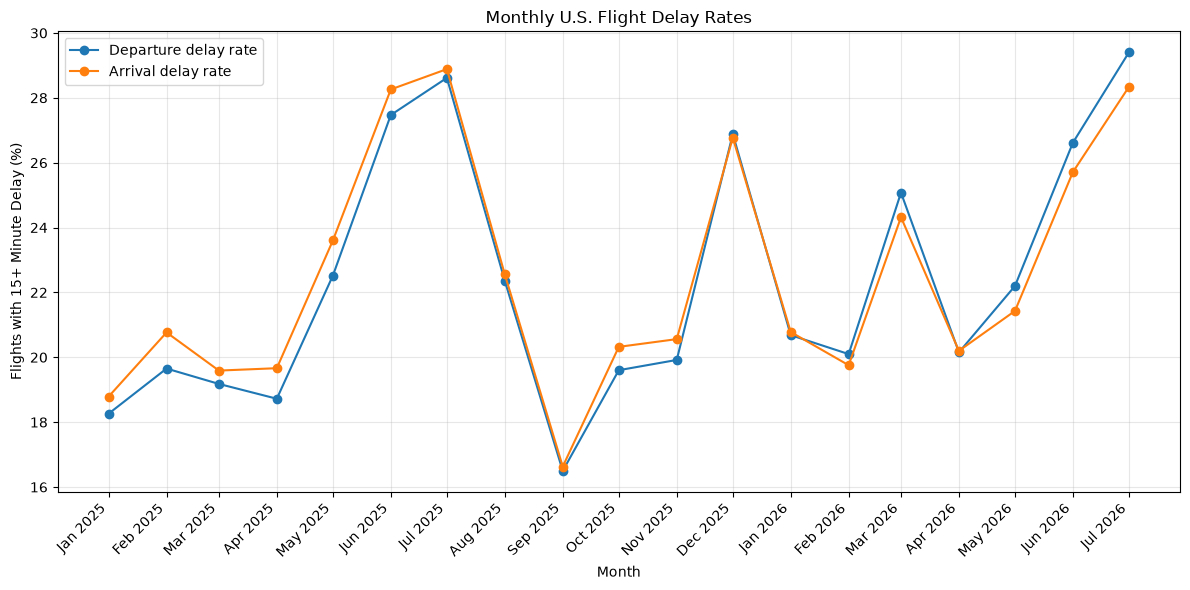

In [45]:
monthly_plot_df = monthly_performance_df.copy()

monthly_plot_df["departure_delay_pct"] = monthly_plot_df["departure_delay_rate"] * 100

monthly_plot_df["arrival_delay_pct"] = monthly_plot_df["arrival_delay_rate"] * 100

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_plot_df["month"],
    monthly_plot_df["departure_delay_pct"],
    marker="o",
    label="Departure delay rate",
)

plt.plot(
    monthly_plot_df["month"],
    monthly_plot_df["arrival_delay_pct"],
    marker="o",
    label="Arrival delay rate",
)

plt.title("Monthly U.S. Flight Delay Rates")
plt.xlabel("Month")
plt.ylabel("Flights with 15+ Minute Delay (%)")
plt.legend()
plt.grid(alpha=0.3)

plt.xticks(
    monthly_plot_df["month"],
    monthly_plot_df["month"].dt.strftime("%b %Y"),
    rotation=45,
    ha="right",
)

plt.tight_layout()

plt.savefig(
    PROJECT_ROOT / "figures" / "monthly_delay_rates.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()



In [46]:
highest_arrival_delay_month = monthly_performance_df.loc[monthly_performance_df["arrival_delay_rate"].idxmax()]
lowest_arrival_delay_month = monthly_performance_df.loc[monthly_performance_df["arrival_delay_rate"].idxmin()]

print(
    "Highest arrival delay rate:",
    highest_arrival_delay_month["month"].strftime("%B %Y"),
    f"({highest_arrival_delay_month['arrival_delay_rate']:.1%})"
)

print(
    "Lowest arrival delay rate:",
    lowest_arrival_delay_month["month"].strftime("%B %Y"),
    f"({lowest_arrival_delay_month['arrival_delay_rate']:.1%})",
)

Highest arrival delay rate: July 2025 (28.9%)
Lowest arrival delay rate: September 2025 (16.6%)


**Figure 1. Monthly flight delay rates.** Departure and arrival delay rates varied substantially over the analysis period and generally moved together. The arrival delay rate reached its highest value in July 2025 at 28.9% and its lowest value in September 2025 at 16.6%, a difference of 12.3 percentage points. Elevated delay rates are visible during June and July in both years, while December 2025 also shows a pronounced increase. The repeated summer pattern suggests that seasonality may contribute to operational reliability, although the 19-month analysis period is too short to establish a long-term seasonal relationship.

### 5.2 Arrival Delay Rates by Airline

In [47]:
# From official BTS airline-code lookup: https://www.bts.gov/topics/airlines-and-airports/airline-codes
carrier_names = {
    "9E": "Endeavor Air (9E)",
    "AA": "American Airlines (AA)",
    "AS": "Alaska Airlines (AS)",
    "B6": "JetBlue Airways (B6)",
    "DL": "Delta Air Lines (DL)",
    "F9": "Frontier Airlines (F9)",
    "G4": "Allegiant Air (G4)",
    "HA": "Hawaiian Airlines (HA)",
    "MQ": "Envoy Air (MQ)",
    "NK": "Spirit Airlines (NK)",
    "OH": "PSA Airlines (OH)",
    "OO": "SkyWest Airlines (OO)",
    "UA": "United Airlines (UA)",
    "WN": "Southwest Airlines (WN)",
    "YX": "Republic Airline (YX)"
}

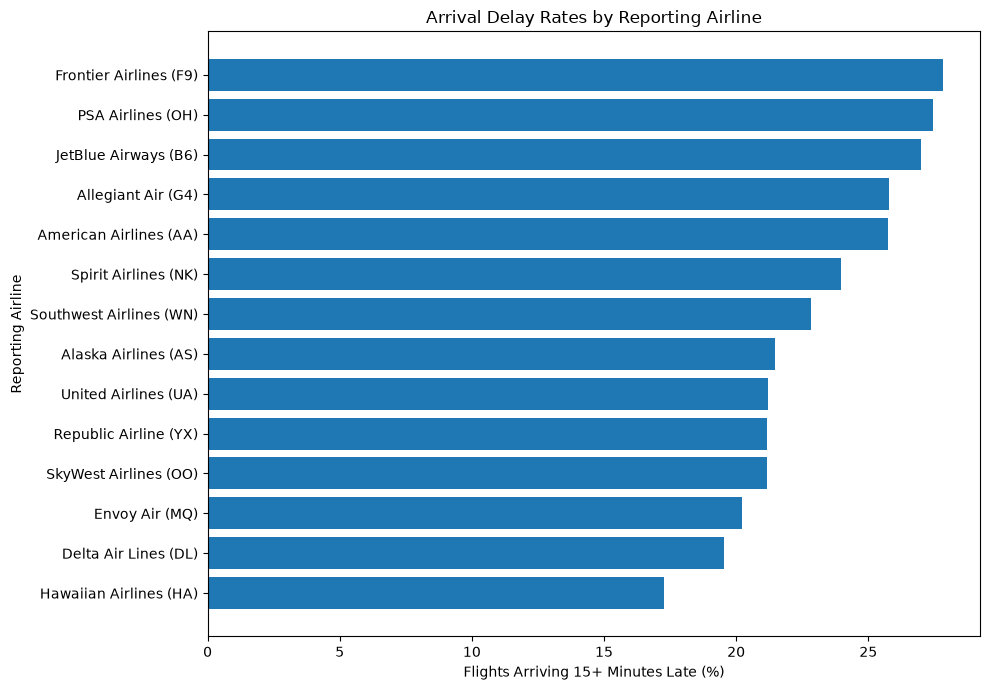

In [48]:
carrier_plot_df = (
    carrier_performance_df
    .sort_values("arrival_delay_rate", ascending=True)
    .copy()
)

carrier_plot_df["carrier_label"] = (
    carrier_plot_df["Reporting_Airline"]
    .map(carrier_names)
    .fillna(carrier_plot_df["Reporting_Airline"])
)

carrier_plot_df["arrival_delay_pct"] = (
    carrier_plot_df["arrival_delay_rate"] * 100
)

plt.figure(figsize=(10, 7))

plt.barh(
    carrier_plot_df["carrier_label"],
    carrier_plot_df["arrival_delay_pct"],
)

plt.title("Arrival Delay Rates by Reporting Airline")
plt.xlabel("Flights Arriving 15+ Minutes Late (%)")
plt.ylabel("Reporting Airline")

plt.tight_layout()

plt.savefig(
    PROJECT_ROOT / "figures" / "carrier_arrival_delay_rates.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [49]:
highest_carrier_delay = carrier_performance_df.loc[
    carrier_performance_df["arrival_delay_rate"].idxmax()
]

lowest_carrier_delay = carrier_performance_df.loc[
    carrier_performance_df["arrival_delay_rate"].idxmin()
]

print(
    "Highest arrival delay rate:",
    highest_carrier_delay["Reporting_Airline"],
    f"({highest_carrier_delay['arrival_delay_rate']:.1%})",
)

print(
    "Lowest arrival delay rate:",
    lowest_carrier_delay["Reporting_Airline"],
    f"({lowest_carrier_delay['arrival_delay_rate']:.1%})",
)

Highest arrival delay rate: F9 (27.8%)
Lowest arrival delay rate: HA (17.3%)


**Figure 2. Arrival delay rates by reporting airline.** Arrival reliability varied substantially across carriers during the January 2025 through July 2026 period. Frontier Airlines (F9) had the highest share of flights arriving at least 15 minutes late at 27.8%, while Hawaiian Airlines (HA) had the lowest at 17.3%, a difference of about 10.6 percentage points. These differences describe observed carrier-level performance but do not by themselves establish that carrier operations caused the variation, because route mix, airport congestion, weather exposure, schedule structure, and other operational factors may differ across airlines.

### 5.3 Airport Departure Delay Rates

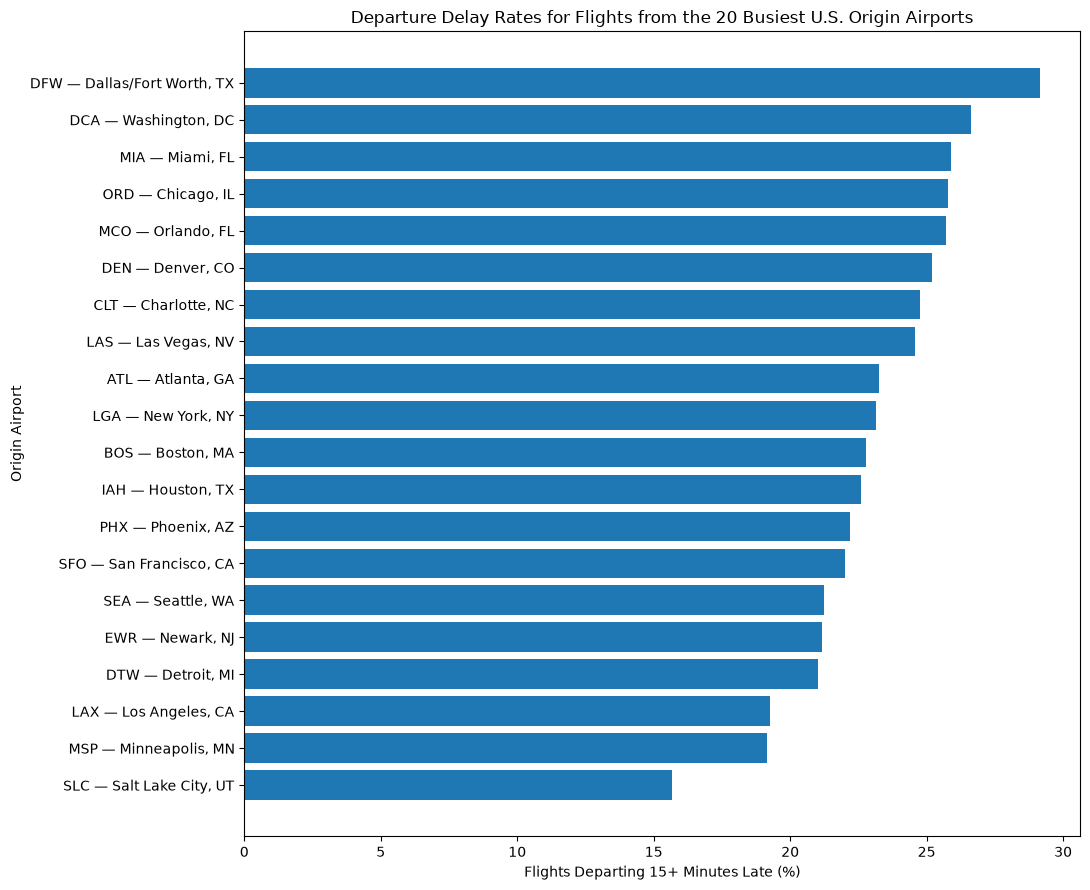

In [50]:
airport_plot_df = (
    busiest_airports_df
    .sort_values("departure_delay_rate", ascending=True)
    .copy()
)

airport_plot_df["departure_delay_pct"] = (
    airport_plot_df["departure_delay_rate"] * 100
)

airport_plot_df["airport_label"] = (
    airport_plot_df["Origin"]
    + " — "
    + airport_plot_df["OriginCityName"]
)

plt.figure(figsize=(11, 9))

plt.barh(
    airport_plot_df["airport_label"],
    airport_plot_df["departure_delay_pct"],
)

plt.title("Departure Delay Rates for Flights from the 20 Busiest U.S. Origin Airports")
plt.xlabel("Flights Departing 15+ Minutes Late (%)")
plt.ylabel("Origin Airport")

plt.tight_layout()

plt.savefig(
    PROJECT_ROOT / "figures" / "airport_departure_delay_rates.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [51]:
highest_airport_delay = busiest_airports_df.loc[
    busiest_airports_df["departure_delay_rate"].idxmax()
]

lowest_airport_delay = busiest_airports_df.loc[
    busiest_airports_df["departure_delay_rate"].idxmin()
]

delay_rate_difference = (
    highest_airport_delay["departure_delay_rate"]
    - lowest_airport_delay["departure_delay_rate"]
)

print(
    "Highest departure delay rate:",
    highest_airport_delay["Origin"],
    f"({highest_airport_delay['departure_delay_rate']:.1%})",
)

print(
    "Lowest departure delay rate:",
    lowest_airport_delay["Origin"],
    f"({lowest_airport_delay['departure_delay_rate']:.1%})",
)

print(
    "Difference:",
    f"{delay_rate_difference * 100:.1f} percentage points",
)

Highest departure delay rate: DFW (29.2%)
Lowest departure delay rate: SLC (15.7%)
Difference: 13.5 percentage points


**Figure 3. Departure delay rates for flights from the 20 busiest U.S. origin
airports.** Departure reliability varied substantially even among airports with consistently high flight volumes. Flights departing Dallas/Fort Worth (DFW) had the highest departure-delay rate at 29.2%, while flights departing Salt Lake City (SLC) had the lowest at 15.7%, a difference of approximately 13.5 percentage points. This variation shows that high traffic volume alone
does not account for the observed differences in departure reliability. Airline mix, route structure, weather exposure, scheduling, airport capacity, and other operational conditions may also contribute.

### 5.4 Delays by Cause

In [52]:
cause_labels = {
    "LateAircraftDelay": "Late Aircraft",
    "CarrierDelay": "Carrier",
    "NASDelay": "National Airspace System",
    "WeatherDelay": "Weather",
    "SecurityDelay": "Security",
}

delay_cause_plot_df = delay_causes_df.copy()

delay_cause_plot_df["cause_label"] = (
    delay_cause_plot_df["cause"].map(cause_labels)
)

delay_cause_plot_df = (
    delay_cause_plot_df
    .sort_values("share_pct", ascending=True)
)

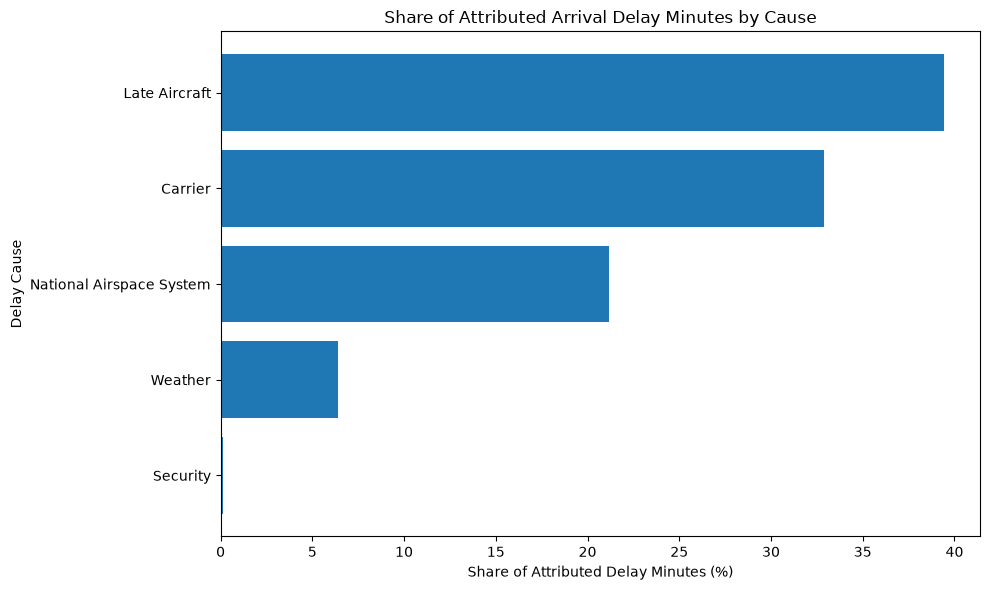

In [53]:
plt.figure(figsize=(10, 6))

plt.barh(
    delay_cause_plot_df["cause_label"],
    delay_cause_plot_df["share_pct"],
)

plt.title("Share of Attributed Arrival Delay Minutes by Cause")
plt.xlabel("Share of Attributed Delay Minutes (%)")
plt.ylabel("Delay Cause")

plt.tight_layout()

plt.savefig(
    PROJECT_ROOT / "figures" / "delay_cause_composition.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [54]:
total_delay_minutes = delay_causes_df["delay_minutes"].sum()

top_two_share = (
    delay_causes_df
    .nlargest(2, "delay_minutes")["delay_minutes"]
    .sum()
    / total_delay_minutes
)

top_three_share = (
    delay_causes_df
    .nlargest(3, "delay_minutes")["delay_minutes"]
    .sum()
    / total_delay_minutes
)

print(
    "Total attributed delay minutes:",
    f"{total_delay_minutes:,.0f}",
)

print(
    "Top two causes:",
    f"{top_two_share:.1%}",
)

print(
    "Top three causes:",
    f"{top_three_share:.1%}",
)

Total attributed delay minutes: 180,014,897
Top two causes: 72.3%
Top three causes: 93.4%


**Figure 4. Share of attributed arrival delay minutes by cause.** Late-arriving aircraft accounted for the largest share of attributed delay minutes at 39.4%, followed by carrier delays at 32.9% and National Airspace System delays at 21.2%. Together, these three categories accounted for approximately 93.4% of attributed delay minutes during the analysis period. Weather accounted for 6.4%, while security-related delays represented less than 0.2%. These figures describe BTS-attributed delay minutes for qualifying delayed flights and should not be interpreted as the causes of all flight disruptions.

### 5.5 Delay-Cause Composition for Flights from Busiest Origin Airports

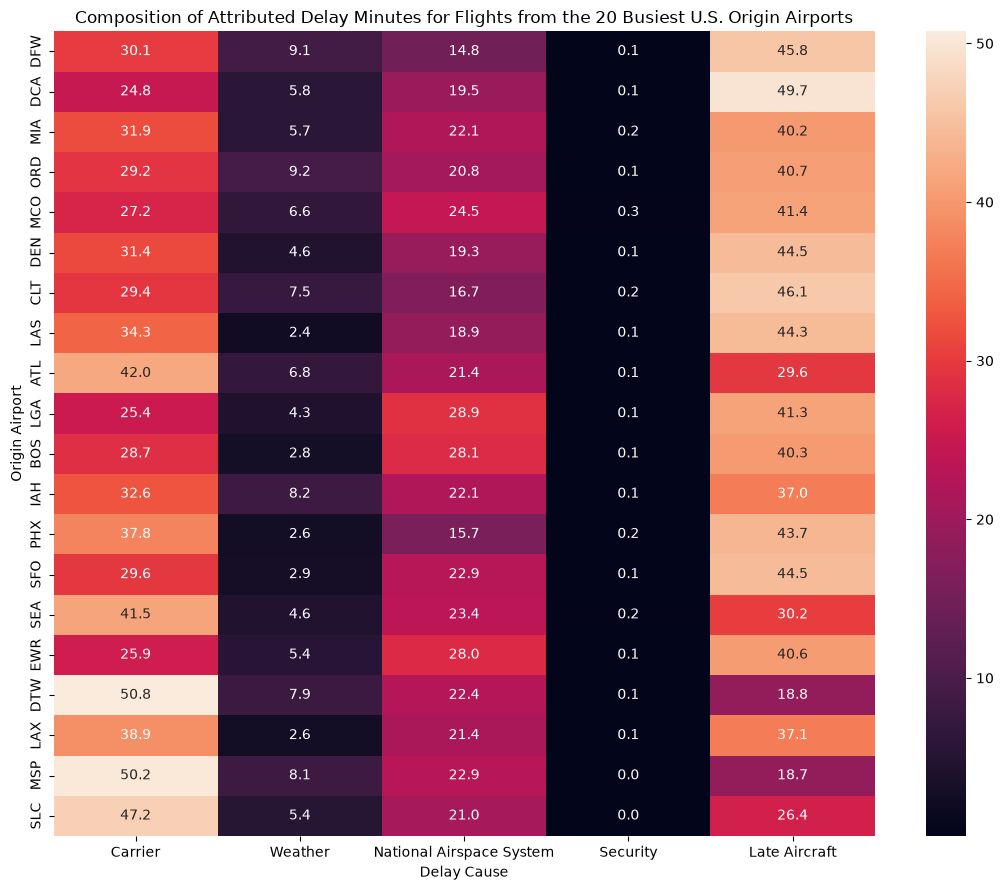

In [55]:
plt.figure(figsize=(11, 9))

sns.heatmap(
    airport_cause_heatmap_df,
    annot=True,
    fmt=".1f",
)

plt.title(
    "Composition of Attributed Delay Minutes for Flights "
    "from the 20 Busiest U.S. Origin Airports"
)
plt.xlabel("Delay Cause")
plt.ylabel("Origin Airport")

plt.tight_layout()

plt.savefig(
    PROJECT_ROOT / "figures"
    / "airport_delay_cause_composition.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

**Figure 5. Composition of attributed delay minutes for flights departing from
the 20 busiest U.S. origin airports.** The mix of BTS-attributed delay causes varies considerably across these origin airports. Late-arriving aircraft account for nearly half of attributed delay minutes for flights departing DCA, while carrier-attributed delays represent approximately half for flights departing DTW and MSP. National Airspace System delays have comparatively
larger shares for flights departing LGA, BOS, and EWR. Weather represents a smaller portion of attributed delay minutes across most of these origin airports, while security-related delays are negligible. These percentages describe the composition of attributed delay minutes and should not be interpreted as showing that the origin airport itself caused the delay or as explaining differences in overall airport delay rates.

## 6. Summary & Interpretation
---

This analysis examined 11,121,962 U.S. flight records across 19 monthly partitions from January 2025 through July 2026. The analysis focused on monthly reliability trends, differences among reporting airlines and major origin airports, and the composition of BTS-attributed delay minutes.

Several patterns emerged from the analysis:

- Flight reliability varied considerably over time. The arrival delay rate reached 28.9% in July 2025 compared with 16.6% in September 2025. Elevated delay rates were also observed during June and July in both years, although the 19-month analysis period is too short to establish a long-term seasonal relationship.

- Reliability differed substantially across reporting airlines. Arrival delay rates ranged from 17.3% for Hawaiian Airlines (HA) to 27.8% for Frontier Airlines (F9). These observed differences should not be interpreted as carrier effects alone because airlines operate different route networks and are exposed to different airports, schedules, weather conditions, and operational environments.

- Meaningful variation was also present among the 20 busiest origin airports. Flights departing Dallas/Fort Worth (DFW) had the highest departure-delay rate at 29.2%, while flights departing Salt Lake City (SLC) had the lowest at 15.7%, a difference of approximately 13.5 percentage points.

- Late-arriving aircraft accounted for the largest share of BTS-attributed delay minutes at 39.4%, followed by carrier delays at 32.9% and National Airspace System delays at 21.2%. Together, these three categories accounted for approximately 93.4% of attributed delay minutes.

- Delay-cause composition also differed by origin airport. Late-aircraft delay represented a particularly large share for flights departing airports such as DCA and DFW, while carrier-attributed delay represented a larger share for flights departing DTW, MSP, and SLC. NAS-related delay represented a comparatively larger share for flights departing LGA, BOS, and EWR.

**Notable observation:** Even within the 20 busiest origin airports, departure-delay rates differed by approximately 13.5 percentage points. Because all of these airports operate at relatively high traffic volumes, this result suggests that traffic volume alone is insufficient to characterize departure reliability. The substantial differences in delay-cause composition
across origin airports further reinforce the need to consider multiple operational dimensions together.

Overall, the findings show that flight reliability varies across time, reporting airlines, origin airports, and attributed delay categories. More advanced analysis would therefore benefit from considering these dimensions jointly rather than treating any single observed factor as a complete explanation of flight reliability.

### Assumptions and Limitations

This analysis is descriptive and does not establish causal relationships. Differences among airlines or airports may reflect route mix, scheduling, weather exposure, airspace constraints, network structure, and other factors that were not controlled for in this project.

The analysis covers January 2025 through July 2026. This provides a large and recent dataset but only one complete calendar year, so repeated patterns should not be interpreted as established long-term trends or seasonality.

Missing operational values were preserved when they represented legitimate flight outcomes. For example, cancelled and diverted flights do not always have normal arrival or elapsed-time measurements, and BTS delay-cause fields are populated only for qualifying delayed flights. Consequently, metrics based on arrival delays or delay causes apply only to records for which those measures are defined.

The full-dataset quality audit also identified 14 nonpositive scheduled elapsed-time values; these invalid measurements were replaced with missing values while the remainder of each affected flight record was retained.

Finally, delay-cause percentages describe the composition of BTS-attributed delay minutes. They do not indicate that a particular cause explains the overall delay rate of an airport or airline.

### Future Extensions

This project establishes a reproducible analytical foundation that could be extended into more advanced machine learning and AI workflows.

Potential next steps include:

- Predicting flight delays and cancellations using schedule, carrier, airport, route, and weather-related features;
- Modeling airport and route reliability using longer historical windows;
- Incorporating external weather and airport-capacity data;
- Detecting emerging disruption patterns and operational anomalies;
- Building an operational intelligence assistant that can summarize current reliability risks and explain the factors contributing to them.

These extensions would require additional validation, feature engineering, and model evaluation beyond the descriptive scope of this project.